# NFW scale function used by the PINN

`ScaleNNPotentialLayer` with `scale="nfw"` ([src/galactoPINNs/layers.py](../src/galactoPINNs/layers.py), `_compute_scale`) multiplies the NN output by

$$s(r) = \frac{\ln(1 + \tilde r/\tilde r_s)}{\tilde r}, \qquad \tilde r = r / x^*,$$

and in the fire_sims / fire_sims_v2 runs $x^* = r_s = 15.62$ kpc (`HALO_RS`), so $\tilde r_s = 1$ and $s = \ln(1 + r/r_s)/(r/r_s)$. Here $r$ is the galactocentric radius.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

R_S = 15.62  # kpc, HALO_RS = x* = cfg["r_s"] in clean_experiments/fire_sims_v2/datasets.py
R_LO, R_HI = 8.0, 12.0

def nfw_scale(r, r_s=R_S):
    x = r / r_s
    return np.log1p(x) / x

for r in (R_LO, R_HI):
    print(f"s({r:4.1f} kpc) = {nfw_scale(r):.4f}")
s_lo, s_hi = nfw_scale(R_LO), nfw_scale(R_HI)
print(f"change over [{R_LO:g}, {R_HI:g}] kpc: {100 * (s_hi / s_lo - 1):+.1f}%")

s( 8.0 kpc) = 0.8074
s(12.0 kpc) = 0.7419
change over [8, 12] kpc: -8.1%


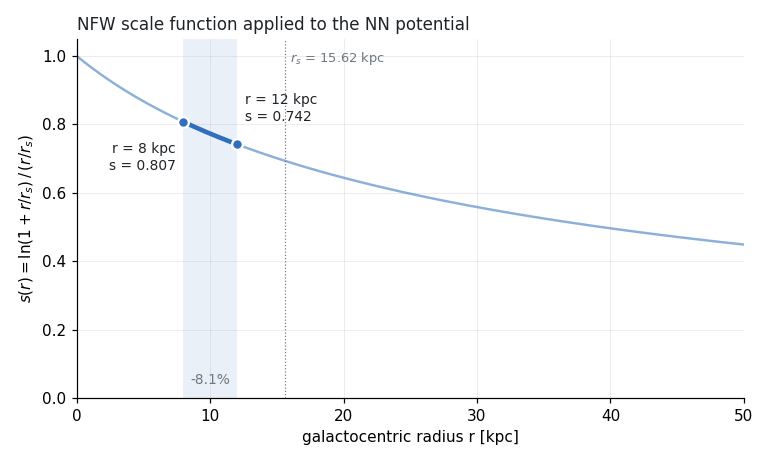

In [2]:
INK, MUTED, LINE, BAND = "#1f2328", "#6e7781", "#2f6fbd", "#2f6fbd"

r = np.linspace(0.05, 50, 2000)
s = nfw_scale(r)
in_band = (r >= R_LO) & (r <= R_HI)

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.axvspan(R_LO, R_HI, color=BAND, alpha=0.10, lw=0)
ax.plot(r, s, color=LINE, lw=1.6, alpha=0.55)
ax.plot(r[in_band], s[in_band], color=LINE, lw=3.0)

for r0, s0, ha, va, dx, dy in ((R_LO, s_lo, "right", "top", -0.6, -0.06),
                               (R_HI, s_hi, "left", "bottom", 0.6, 0.06)):
    ax.plot(r0, s0, "o", ms=7, color=LINE, mec="white", mew=1.5, zorder=3)
    ax.annotate(f"r = {r0:g} kpc\ns = {s0:.3f}", (r0, s0), xytext=(r0 + dx, s0 + dy),
                ha=ha, va=va, fontsize=9, color=INK)

ax.text((R_LO + R_HI) / 2, 0.03, f"{100 * (s_hi / s_lo - 1):+.1f}%", ha="center",
        va="bottom", fontsize=9, color=MUTED, transform=ax.get_xaxis_transform())
ax.axvline(R_S, color=MUTED, lw=0.8, ls=":")
ax.text(R_S + 0.4, 0.97, rf"$r_s$ = {R_S} kpc", color=MUTED, fontsize=8.5, va="top",
        transform=ax.get_xaxis_transform())

ax.set_xlim(0, 50)
ax.set_ylim(0, 1.05)
ax.set_xlabel("galactocentric radius r [kpc]")
ax.set_ylabel(r"$s(r) = \ln(1 + r/r_s)\,/\,(r/r_s)$")
ax.set_title("NFW scale function applied to the NN potential", loc="left", fontsize=11, color=INK)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.grid(alpha=0.25, lw=0.6)
fig.tight_layout()
plt.show()